In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Read files
X = np.loadtxt("x.dat")
y = np.loadtxt("y.dat")

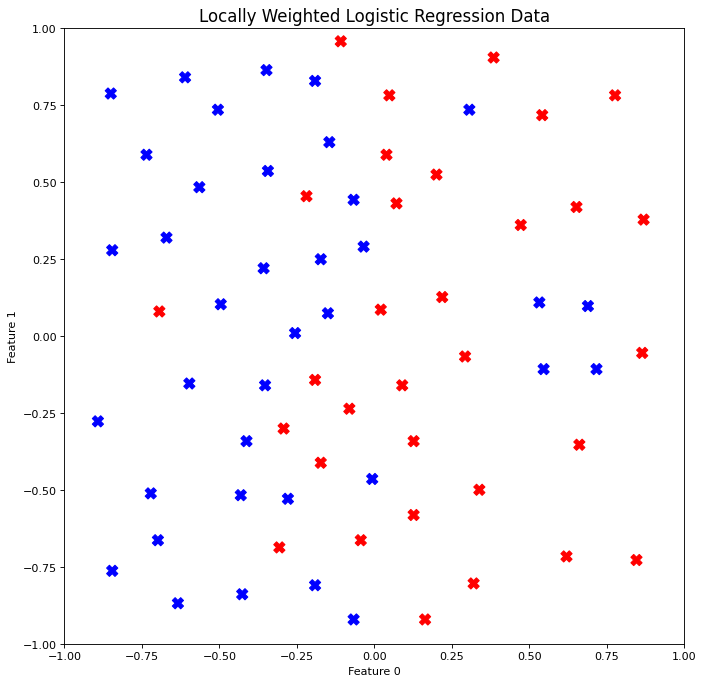

In [ ]:
fig,ax1 = plt.subplots(figsize=(10,10),dpi=80)
scatter = ax1.scatter(X[:,0],X[:,1],c=y,cmap="bwr",marker='X',s=100)

ax1.set_xlim(-1,1)
ax1.set_ylim(-1,1)
ax1.set_title("Locally Weighted Logistic Regression Data", fontsize=15)
ax1.set_xlabel("Feature 0")
ax1.set_ylabel("Feature 1")

plt.show()



In [11]:
# LOCALLY WEIGHTED LOGISTICAL REGRESSION

def sigmoid(z):
    return 1/(1+np.exp(-z))

def lwlr(X,y,x,tau):
    m,n = X.shape
    g = np.ones(n) #Gradient
    theta = np.zeros(n) #Parameter
    
    pow = -1*((np.sum((X-x)**2,axis=1))/(2*tau*tau))
    w = np.exp(pow)
    while(np.linalg.norm(g)>1e-6):
        h = sigmoid(X@theta)
        z = w*(y-h)
        g = X.T@z - (1e-4)*theta
        
        W_diag = -w * h * (1 - h)
        H = (X.T * W_diag) @ X - (1e-4 * np.eye(n))
        theta-=np.linalg.solve(H,g) #Readymade newton solving function
    return int(sigmoid(x@theta)>=0.5)   
    

In [7]:
def plot_lwlr(X,y,tau,resolution=50):
    x0_range = np.linspace(-1,1,resolution) # Creates array of -1 to 1 with resolution divisions
    x1_range = np.linspace(-1,1,resolution)
    
    # Standard procedure to create list of grid points !
    xx,yy = np.meshgrid(x0_range,x1_range) # 2D matrix of every coordinate
    grid_points = np.c_[xx.ravel(),yy.ravel()] # Ravel converts stuff to 1D matrix and c_ stack columns
    
    model_preds = np.array([lwlr(X,y,pt,tau) for pt in grid_points])
    Z = model_preds.reshape(xx.shape) # important to reshape !!
    
    fig,ax = plt.subplots(figsize=(10,8),dpi=80)
    
    background = ax.contourf(xx,yy,Z,alpha=0.2,cmap="bwr") #bwr : 0 to blue 1 to red
    
    ax.contour(xx,yy,Z,levels=[0.5],colors="black",linewidths=1)
    
    scatter = ax.scatter(X[:,0],X[:,1],c=y,cmap="bwr",s=100,marker='*',linewidth=0.5)
    
    ax.set_title(f"LWLR Decision Surface (Tau = {tau})", fontsize=14)
    ax.set_xlabel("Feature 0", fontsize=12)
    ax.set_ylabel("Feature 1", fontsize=12)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    
    
    
    
    

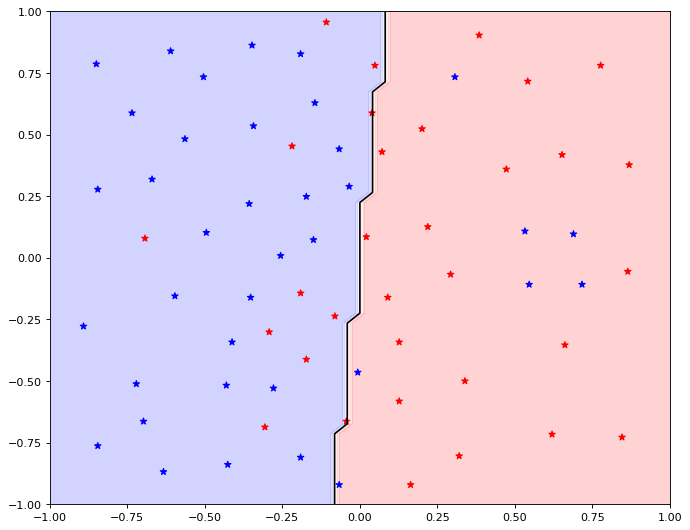

In [20]:
plot_lwlr(X,y,tau=0.4,resolution=50)